In [1]:
import pandas as pd
import os
import numpy as np
import smarts_cerebellum.globals as gl
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scripts.piecewise_linear_SI import piecewise_lin_pred

# DTI metrics
dti = pd.read_csv(os.path.join(gl.baseDir, 'DTI', 'JHU_MNI_DTI_flip.tsv'), sep = '\t')
dti = dti[dti.isPatient == 1] # just patients

# behavioural residuals
residuals_week = pd.read_csv(os.path.join(gl.baseDir, 'behavioural', 'piecewise_SI_residuals_week.tsv'), sep = '\t')
residuals_time_invariant = pd.read_csv(os.path.join(gl.baseDir, 'behavioural', 'piecewise_SI_residuals_time_invariant.tsv'), sep = '\t')


# cerebellum GMV
regions = ['M1L', 'M2L', 'M3L', 'M4L', 'M1R', 'M2R','M3R', 'M4R', 'S5L', 'S5R']
cerebel = pd.read_csv(os.path.join(gl.baseDir, 'MNISymC_GM', 'summary_MNISymC_Nettekoven_2024_GM_mod.tsv'), sep = '\t')
cerebel = cerebel[cerebel.isPatient==1] # just patients
cerebel = cerebel[cerebel.regionname.isin(regions)]
cerebel['hemisphere'] = cerebel.regionname.str[2]

/localscratch/tmp/ipykernel_27361/3441233957.py:11: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  dti = pd.read_csv(os.path.join(gl.baseDir, 'DTI', 'JHU_MNI_DTI_flip.tsv'), sep = '\t')


# Mean diffusivity ($\frac{\lambda_1 + \lambda_2 + \lambda_3}{3}$)

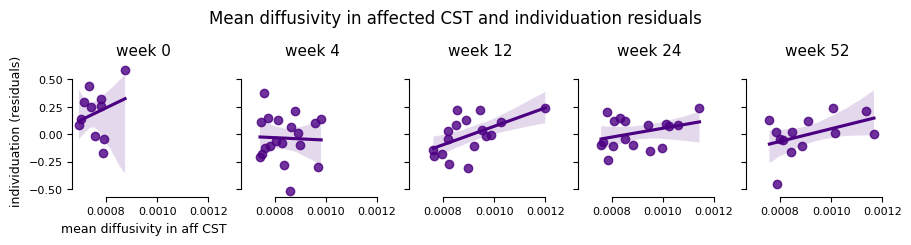

**Pearson R and p-value for MD in affected CST and individuation* residuals* 

week 0: r = 0.26028427683791433, p-value = 0.4395259435230049
week 4: r = -0.0405441899462337, p-value = 0.8691036844773257
week 12: r = 0.5476314412430792, p-value = 0.022873883286694843
week 24: r = 0.3410144280722646, p-value = 0.1804039121835582
week 52: r = 0.4405894456484877, p-value = 0.1318497934902369


In [13]:
# affected: ipsilesional CST, paretic hand
fig, axs = plt.subplots(1, 5, figsize = (9,2), sharey = True, sharex = True, constrained_layout = True)
for i, week in enumerate(gl.weeks):
    resid_plot = residuals_week[residuals_week.Week == week]
    dti_plot = dti[(dti.Week == week) & (dti.metric == 'mean_diffusivity') & (dti.regionname == 'CST_R')]
    behav_dti_plot = pd.merge(dti_plot, resid_plot, on = ['subj_id', 'Week'], suffixes = ('_dti', '_behav'))

    ax = axs[i]
    sns.regplot(x = 'mean', y = 'residuals', data = behav_dti_plot, ax = ax, color = 'indigo')

    ax.set_ylabel('')
    ax.set_xlabel('')

    ax.set_title(f'week {week}')
    

axs[0].set_ylabel("individuation (residuals)")
axs[0].set_xlabel(f"mean diffusivity in aff CST")
fig.suptitle(f"Mean diffusivity in affected CST and individuation residuals", y = 1.15)

sns.despine(trim = True)
plt.show()


print("**Pearson R and p-value for MD in affected CST and individuation* residuals* \n")
for week in gl.weeks:
    resid_plot = residuals_week[residuals_week.Week == week]
    dti_plot = dti[(dti.Week == week) & (dti.metric == 'mean_diffusivity') & (dti.regionname == 'CST_R')]
    behav_dti_plot = pd.merge(dti_plot, resid_plot, on = ['subj_id', 'Week'], suffixes = ('_dti', '_behav'))

    r_stat, p_stat = stats.pearsonr(behav_dti_plot['mean'], behav_dti_plot['residuals'])
    print(f'week {week}: r = {r_stat}, p-value = {p_stat}')


# Axial diffusivity ($\lambda_1$)

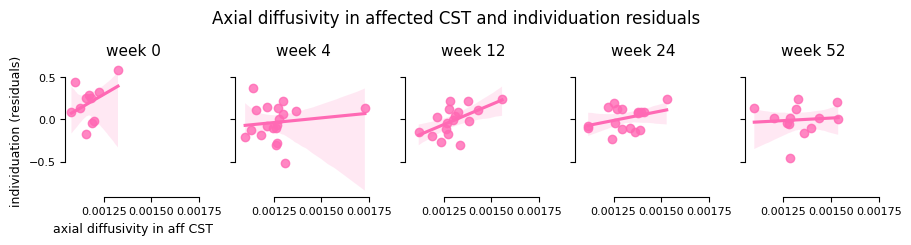

**Pearson R and p-value for AD in affected CST and individuation* residuals* 

week 0: r = 0.3850193685689594, p-value = 0.24228752197153672
week 4: r = 0.1389785301039845, p-value = 0.5704205489578559
week 12: r = 0.5574683560248122, p-value = 0.020072493953413824
week 24: r = 0.3419912081412118, p-value = 0.17907805879627348
week 52: r = 0.08305080827084801, p-value = 0.787362692459445


In [2]:
# affected: ipsilesional CST, paretic hand
fig, axs = plt.subplots(1, 5, figsize = (9,2), sharey = True, sharex = True, constrained_layout = True)
for i, week in enumerate(gl.weeks):
    resid_plot = residuals_week[residuals_week.Week == week]
    dti_plot = dti[(dti.Week == week) & (dti.metric == 'lambda_1') & (dti.regionname == 'CST_R')]
    behav_dti_plot = pd.merge(dti_plot, resid_plot, on = ['subj_id', 'Week'], suffixes = ('_dti', '_behav'))

    ax = axs[i]
    sns.regplot(x = 'mean', y = 'residuals', data = behav_dti_plot, ax = ax, color = 'hotpink')

    ax.set_ylabel('')
    ax.set_xlabel('')

    ax.set_title(f'week {week}')
    

axs[0].set_ylabel("individuation (residuals)")
axs[0].set_xlabel(f"axial diffusivity in aff CST")
fig.suptitle(f"Axial diffusivity in affected CST and individuation residuals", y = 1.15)

sns.despine(trim = True)
plt.show()


print("**Pearson R and p-value for AD in affected CST and individuation* residuals* \n")
for week in gl.weeks:
    resid_plot = residuals_week[residuals_week.Week == week]
    dti_plot = dti[(dti.Week == week) & (dti.metric == 'lambda_1') & (dti.regionname == 'CST_R')]
    behav_dti_plot = pd.merge(dti_plot, resid_plot, on = ['subj_id', 'Week'], suffixes = ('_dti', '_behav'))

    r_stat, p_stat = stats.pearsonr(behav_dti_plot['mean'], behav_dti_plot['residuals'])
    print(f'week {week}: r = {r_stat}, p-value = {p_stat}')


# Radial diffusivity ($\frac{\lambda_2 + \lambda_3}{2}$)

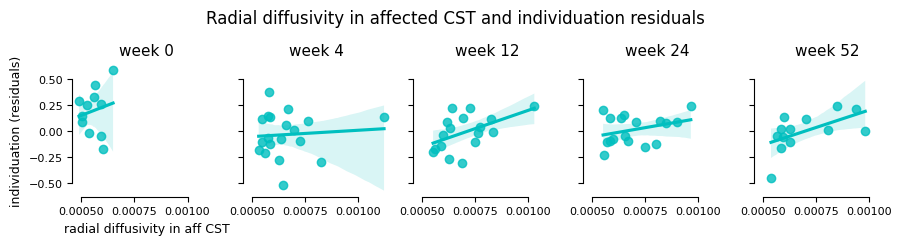

**Pearson R and p-value for RD in affected CST and individuation* residuals* 

week 0: r = 0.17713271590967428, p-value = 0.6023427776974543
week 4: r = 0.07999020186704277, p-value = 0.7447871888083388
week 12: r = 0.5052042793653809, p-value = 0.038585550085044606
week 24: r = 0.32982926501107196, p-value = 0.19605259094741564
week 52: r = 0.5636733461453722, p-value = 0.04483055507354618


In [3]:
# affected: ipsilesional CST, paretic hand
fig, axs = plt.subplots(1, 5, figsize = (9,2), sharey = True, sharex = True, constrained_layout = True)
for i, week in enumerate(gl.weeks):
    resid_plot = residuals_week[residuals_week.Week == week]
    dti_plot = dti[(dti.Week == week) & (dti.metric == 'radial_diffusivity') & (dti.regionname == 'CST_R')]
    behav_dti_plot = pd.merge(dti_plot, resid_plot, on = ['subj_id', 'Week'], suffixes = ('_dti', '_behav'))

    ax = axs[i]
    sns.regplot(x = 'mean', y = 'residuals', data = behav_dti_plot, ax = ax, color = 'c')

    ax.set_ylabel('')
    ax.set_xlabel('')

    ax.set_title(f'week {week}')
    

axs[0].set_ylabel("individuation (residuals)")
axs[0].set_xlabel(f"radial diffusivity in aff CST")
fig.suptitle(f"Radial diffusivity in affected CST and individuation residuals", y = 1.15)

sns.despine(trim = True)
plt.show()


print("**Pearson R and p-value for RD in affected CST and individuation* residuals* \n")
for week in gl.weeks:
    resid_plot = residuals_week[residuals_week.Week == week]
    dti_plot = dti[(dti.Week == week) & (dti.metric == 'radial_diffusivity') & (dti.regionname == 'CST_R')]
    behav_dti_plot = pd.merge(dti_plot, resid_plot, on = ['subj_id', 'Week'], suffixes = ('_dti', '_behav'))

    r_stat, p_stat = stats.pearsonr(behav_dti_plot['mean'], behav_dti_plot['residuals'])
    print(f'week {week}: r = {r_stat}, p-value = {p_stat}')


# Fractional anisotropy

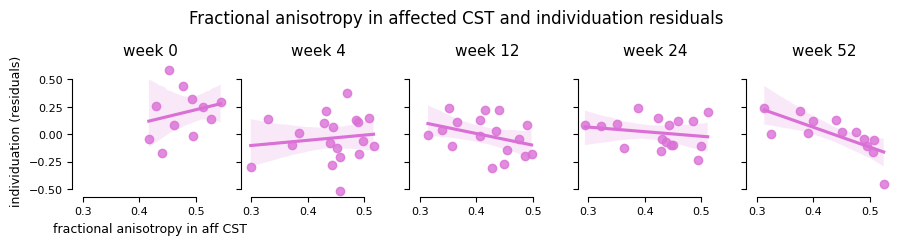

**Pearson R and p-value for FA in affected CST and individuation* residuals* 

week 0: r = 0.2278951476753472, p-value = 0.5003326705655894
week 4: r = 0.1322767640965585, p-value = 0.589321669694582
week 12: r = -0.35083294646798163, p-value = 0.16737137196567417
week 24: r = -0.18795542023267336, p-value = 0.4700429542018544
week 52: r = -0.7185898622762448, p-value = 0.00565234168195844


In [4]:
# affected: ipsilesional CST, paretic hand
fig, axs = plt.subplots(1, 5, figsize = (9,2), sharey = True, sharex = True, constrained_layout = True)
for i, week in enumerate(gl.weeks):
    resid_plot = residuals_week[residuals_week.Week == week]
    dti_plot = dti[(dti.Week == week) & (dti.metric == 'FaMap') & (dti.regionname == 'CST_R')]
    behav_dti_plot = pd.merge(dti_plot, resid_plot, on = ['subj_id', 'Week'], suffixes = ('_dti', '_behav'))

    ax = axs[i]
    sns.regplot(x = 'mean', y = 'residuals', data = behav_dti_plot, ax = ax, color = 'orchid')

    ax.set_ylabel('')
    ax.set_xlabel('')

    ax.set_title(f'week {week}')
    

axs[0].set_ylabel("individuation (residuals)")
axs[0].set_xlabel(f"fractional anisotropy in aff CST")
fig.suptitle(f"Fractional anisotropy in affected CST and individuation residuals", y = 1.15)

sns.despine(trim = True)
plt.show()


print("**Pearson R and p-value for FA in affected CST and individuation* residuals* \n")
for week in gl.weeks:
    resid_plot = residuals_week[residuals_week.Week == week]
    dti_plot = dti[(dti.Week == week) & (dti.metric == 'FaMap') & (dti.regionname == 'CST_R')]
    behav_dti_plot = pd.merge(dti_plot, resid_plot, on = ['subj_id', 'Week'], suffixes = ('_dti', '_behav'))

    r_stat, p_stat = stats.pearsonr(behav_dti_plot['mean'], behav_dti_plot['residuals'])
    print(f'week {week}: r = {r_stat}, p-value = {p_stat}')


# Cerebellar GMV

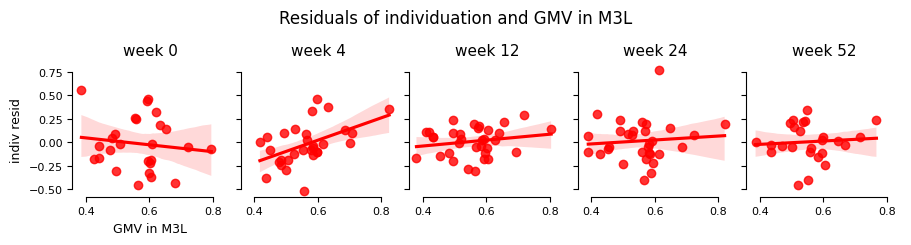

**Pearson R and p-value for indiv resid and GMV in M3L (cerebellum)** 

week 0: r = -0.1262786837877748, p-value = 0.5387537899019849
week 4: r = 0.4914014407693991, p-value = 0.0058210446434934105
week 12: r = 0.19071249215694297, p-value = 0.28773080057274153
week 24: r = 0.0891037514415742, p-value = 0.6335960317912297
week 52: r = 0.07827571689061957, p-value = 0.7099576781657349


In [5]:
fig, axs = plt.subplots(1, 5, figsize = (9,2), sharey = True, sharex = True, constrained_layout = True)
for i, week in enumerate(gl.weeks):
    cerebel_plot = cerebel[(cerebel.Week == week) & (cerebel.regionname == 'M3L')]
    resid_plot = residuals_week[residuals_week.Week == week]
    cerebel_resid_plot = pd.merge(resid_plot, cerebel_plot, on = ['subj_id', 'Week'], suffixes = ('_resid', '_cerebel'))

    ax = axs[i]
    sns.regplot(x = 'mean', y = 'residuals', data = cerebel_resid_plot, ax = ax, color = 'red')

    ax.set_ylabel('')
    ax.set_xlabel('')

    ax.set_title(f'week {week}')
    

axs[0].set_xlabel("GMV in M3L")
axs[0].set_ylabel(f"indiv resid")
fig.suptitle(f"Residuals of individuation and GMV in M3L", y = 1.15)


sns.despine(trim = True)
plt.show()


print("**Pearson R and p-value for indiv resid and GMV in M3L (cerebellum)** \n")
for week in gl.weeks:
    cerebel_plot = cerebel[(cerebel.Week == week) & (cerebel.regionname == 'M3L')]
    resid_plot = residuals_week[residuals_week.Week == week]
    cerebel_resid_plot = pd.merge(resid_plot, cerebel_plot, on = ['subj_id', 'Week'], suffixes = ('_resid', '_cerebel'))

    r_stat, p_stat = stats.pearsonr(cerebel_resid_plot['mean'], cerebel_resid_plot['residuals'])
    print(f'week {week}: r = {r_stat}, p-value = {p_stat}')

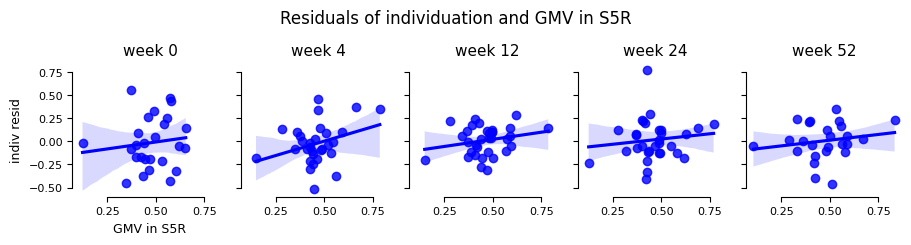

**Pearson R and p-value for indiv resid and GMV in S5R (cerebellum)** 

week 0: r = 0.1238671909348798, p-value = 0.5465968451368417
week 4: r = 0.31871694048020666, p-value = 0.0860523904454739
week 12: r = 0.22569654365597336, p-value = 0.20662276756334064
week 24: r = 0.12433997336695962, p-value = 0.5051299137741393
week 52: r = 0.17809499411161878, p-value = 0.39436653588402415


In [6]:
fig, axs = plt.subplots(1, 5, figsize = (9,2), sharey = True, sharex = True, constrained_layout = True)
for i, week in enumerate(gl.weeks):
    cerebel_plot = cerebel[(cerebel.Week == week) & (cerebel.regionname == 'S5R')]
    resid_plot = residuals_week[residuals_week.Week == week]
    cerebel_resid_plot = pd.merge(resid_plot, cerebel_plot, on = ['subj_id', 'Week'], suffixes = ('_resid', '_cerebel'))

    ax = axs[i]
    sns.regplot(x = 'mean', y = 'residuals', data = cerebel_resid_plot, ax = ax, color = 'blue')

    ax.set_ylabel('')
    ax.set_xlabel('')

    ax.set_title(f'week {week}')
    

axs[0].set_xlabel("GMV in S5R")
axs[0].set_ylabel(f"indiv resid")
fig.suptitle(f"Residuals of individuation and GMV in S5R", y = 1.15)


sns.despine(trim = True)
plt.show()


print("**Pearson R and p-value for indiv resid and GMV in S5R (cerebellum)** \n")
for week in gl.weeks:
    cerebel_plot = cerebel[(cerebel.Week == week) & (cerebel.regionname == 'S5R')]
    resid_plot = residuals_week[residuals_week.Week == week]
    cerebel_resid_plot = pd.merge(resid_plot, cerebel_plot, on = ['subj_id', 'Week'], suffixes = ('_resid', '_cerebel'))

    r_stat, p_stat = stats.pearsonr(cerebel_resid_plot['mean'], cerebel_resid_plot['residuals'])
    print(f'week {week}: r = {r_stat}, p-value = {p_stat}')

The next thing we want to look at are the residuals. So Jing fitted a piecewise function to the plot of strength against individuation (for each time point, and for all time points together). There is some amount of variance that is explained by this line; there is also unexplained variance in the data (model did not explain this). So this would be the difference between the observed value (y_obs = individuation) and the fitted value (y_hat) from the model.

This piecewise function explains some amount of the variance: strength (x) explains some amount of the variance in individuation (y) (up to about 60% recovery of strength). So the measure we have for individuation is partly explained by strength. Now, we are interested in the portion that is *not* explained by strength - this is the residual. The residuals are (I think) higher for the latter portion of the piecewise function. So there is a greater amount of recovery in individuation that is not explained by strength (though does it really recover here?), meaning we are interested in seeing what else could explain this individuation.

We should consider that the experimental measure for strength and individuation measure compared to FMH - what does FMH cover that is not covered by our experimental measures?

# Jing's plots

In [7]:
# behavioural metrics
behav = pd.read_csv(os.path.join(gl.baseDir, 'behavioural', 'summary_paretic.dat'), sep = '\t')
behav.rename(columns = {'subj_name': 'subj_id', 'week': 'Week'}, inplace = True)
behav['subj_id'] = behav['subj_id'].str.strip()
behav.loc[behav['Week']==1, 'Week'] = 0

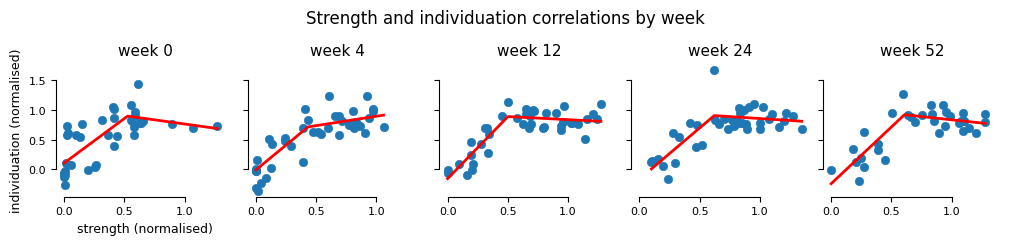

In [8]:
# plot behavioural strength v individuation, and add the curvilinear function (for each week)

fig, axs = plt.subplots(1, 5, figsize = (10,2), sharex = True, sharey = True, constrained_layout = True)
for i, week in enumerate(gl.weeks):

    # get line for each week
    behav_week = behav[behav.Week == week]
    x = (behav_week['mvc_norm'])
    y = (behav_week['indiv_norm'])

    res_for_week = residuals_week[residuals_week.Week == week]
    params = res_for_week[['x_star', 'beta_0', 'beta_1', 'beta_2']].drop_duplicates().values[0]

    ax = axs[i]
    sns.scatterplot(x = 'mvc_norm', y = 'indiv_norm', data = behav[behav.Week == week], ax = ax, edgecolor = None)
    sns.despine(trim = True)

    # plot piecewise regression line
    x_grid = np.linspace(x.min(), x.max(), 200)
    y_grid = piecewise_lin_pred(x_grid, params) # makes the line for each week
    ax.plot(x_grid, y_grid, color='red', lw=2)

    ax.set_ylabel('')
    ax.set_xlabel('')
    #ax.set_xticks([])
    ax.set_title(f'week {week}')
    

axs[0].set_ylabel("individuation (normalised)")
axs[0].set_xlabel("strength (normalised)")

fig.suptitle("Strength and individuation correlations by week", y = 1.15)
plt.show()


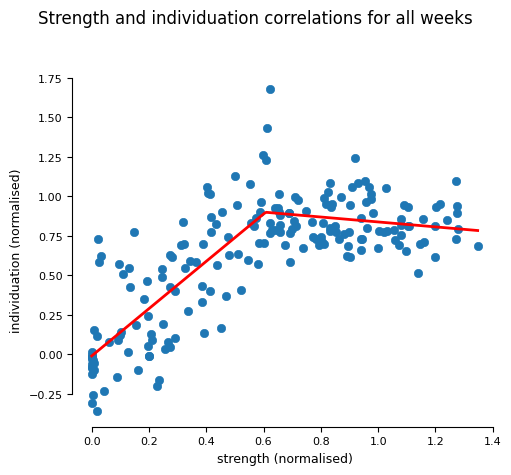

In [9]:
fig, ax = plt.subplots(figsize = (5, 4), sharex = True, sharey = True, constrained_layout = True)

# get line for each week
x = (behav['mvc_norm'])
y = (behav['indiv_norm'])

params = residuals_time_invariant[['x_star', 'beta_0', 'beta_1', 'beta_2']].drop_duplicates().values[0]

sns.scatterplot(x = 'mvc_norm', y = 'indiv_norm', data = behav, ax = ax, edgecolor = None)
sns.despine(trim = True)

# plot piecewise regression line
x_grid = np.linspace(x.min(), x.max(), 200)
y_grid = piecewise_lin_pred(x_grid, params)
ax.plot(x_grid, y_grid, color='red', lw=2)
    

ax.set_ylabel("individuation (normalised)")
ax.set_xlabel("strength (normalised)")

fig.suptitle("Strength and individuation correlations for all weeks", y = 1.15)
plt.show()
